In [141]:
import numpy as np
import os
import pyvista as pv
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from skimage.metrics import structural_similarity as ssim

In [142]:
grid = pv.read("cylinder2d.vti")

dims = grid.dimensions  # (640, 80, 1501)
print(dims)
OUTPUT_DIR = "UNET_2D_Cylinder_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

(640, 80, 1501)


In [143]:
# Extract and reshape properly
#Why order='F' is Critical
#VTK uses Fortran-style (column-major) memory layout
#Without this:#Flow field becomes physically incorrect
#Vortices appear distorted or random

u = grid['u'].reshape(dims, order='F') 
v = grid['v'].reshape(dims, order='F') 
print("Reshaped u:", u.shape)  # should be (640, 80, 1501)
print("Reshaped v:", v.shape)  # should be (640, 80, 1501)

Reshaped u: (640, 80, 1501)
Reshaped v: (640, 80, 1501)


In [144]:
# Convert (x, y, t) → (t, x, y)
u = np.transpose(u, (2, 0, 1))
v = np.transpose(v, (2, 0, 1))

flow = np.stack([u, v], axis=-1)
print("ML shape:", flow.shape)  # (1501, 640, 80, 2)

ML shape: (1501, 640, 80, 2)


In [145]:
flow = flow[:, ::2, ::1, :]   # → (1501, 160, 40, 2)

print("Downsampled:", flow.shape)

flow_min = flow.min()
flow_max = flow.max()

flow = (flow - flow_min) / (flow_max - flow_min)

Downsampled: (1501, 320, 80, 2)


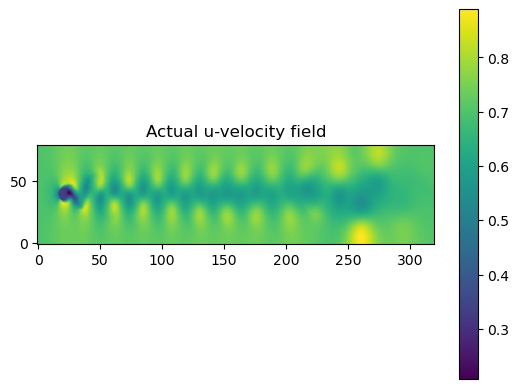

In [146]:
plt.imshow(flow[900,:,:,0].T, origin='lower')
plt.title("Actual u-velocity field")
plt.savefig(os.path.join(OUTPUT_DIR, f"u_velocity_field.png"), dpi=1200)
plt.colorbar()
plt.show()

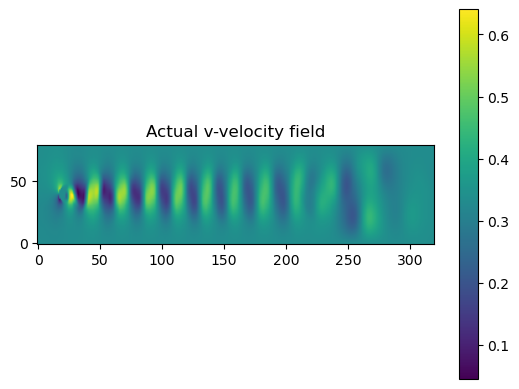

In [147]:
plt.imshow(flow[900,:,:,1].T, origin='lower')
plt.title("Actual v-velocity field")
plt.savefig(os.path.join(OUTPUT_DIR, f"v_velocity_field.png"), dpi=1200)
plt.colorbar()
plt.show()

In [148]:
def create_dataset(data):
    X, y = [], []
    for i in range(len(data) - 1):
        X.append(data[i])
        y.append(data[i+1])
    return np.array(X), np.array(y)

X, y = create_dataset(flow)

In [149]:
# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [150]:
#UNET Model for next-step prediction
def build_unet(input_shape):
    inputs = layers.Input(input_shape)

    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)

    b = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)

    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c3])
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c2])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u2)

    u3 = layers.UpSampling2D()(c4)
    u3 = layers.concatenate([u3, c1])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u3)

    outputs = layers.Conv2D(2, 1, activation='linear')(c5)

    return models.Model(inputs, outputs)

model = build_unet(X_train.shape[1:])
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 320, 80, 2)        │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_11 (Conv2D)            │ (None, 320, 80, 64)       │           1,216 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_12 (Conv2D)            │ (None, 320, 80, 64)       │          36,928 │ conv2d_11[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_3               │ (None, 160, 40, 64)       │               0 │ conv2d_12[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_13 (Conv2D)            │ (None, 160, 40, 128)      │          73,856 │ max_pooling2d_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_14 (Conv2D)            │ (None, 160, 40, 128)      │         147,584 │ conv2d_13[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_4               │ (None, 80, 20, 128)       │               0 │ conv2d_14[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_15 (Conv2D)            │ (None, 80, 20, 256)       │         295,168 │ max_pooling2d_4[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_16 (Conv2D)            │ (None, 80, 20, 256)       │         590,080 │ conv2d_15[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_5               │ (None, 40, 10, 256)       │               0 │ conv2d_16[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_17 (Conv2D)            │ (None, 40, 10, 512)       │       1,180,160 │ max_pooling2d_5[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d_3               │ (None, 80, 20, 512)       │               0 │ conv2d_17[0][0]            │
│ (UpSampling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_3 (Concatenate)   │ (None, 80, 20, 768)       │               0 │ up_sampling2d_3[0][0],     │
│                               │                           │                 │ conv2d_16[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_18 (Conv2D)            │ (None, 80, 20, 256)       │       1,769,728 │ concatenate_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d_4               │ (None, 160, 40, 256)      │               

 Total params: 4,648,002 (17.73 MB)

 Trainable params: 4,648,002 (17.73 MB)

 Non-trainable params: 0 (0.00 B)

In [154]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=4
)

Epoch 1/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 299s 1s/step - loss: 8.0903e-04 - val_loss: 3.6455e-05
Epoch 2/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 5400s 23s/step - loss: 2.3841e-05 - val_loss: 1.4546e-05
Epoch 3/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - loss: 1.0868e-05 - val_loss: 2.2394e-05
Epoch 4/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 302s 1s/step - loss: 7.9625e-06 - val_loss: 6.5337e-06
Epoch 5/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - loss: 7.3748e-06 - val_loss: 1.6647e-05
Epoch 6/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 581s 2s/step - loss: 6.6335e-06 - val_loss: 4.1856e-06
Epoch 7/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 285s 1s/step - loss: 5.1389e-06 - val_loss: 7.1961e-06
Epoch 8/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 282s 1s/step - loss: 5.8639e-06 - val_loss: 8.3231e-06
Epoch 9/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - loss: 7.8946e-06 - val_loss: 3.3955e-06
Epoch 10/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - loss: 4.1845e-06 - val_loss: 1.0166e-05
Epoch 11/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 276s 1

In [155]:
y_pred = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step


In [156]:
mse = np.mean((y_test - y_pred)**2)

ssim_vals = []
for i in range(len(y_test)):
    ssim_vals.append(
        ssim(y_test[i,:,:,0], y_pred[i,:,:,0], data_range=1.0)
    )

print("MSE:", mse)
print("Mean SSIM:", np.mean(ssim_vals))

MSE: 1.3378519e-06
Mean SSIM: 0.9997704679874773


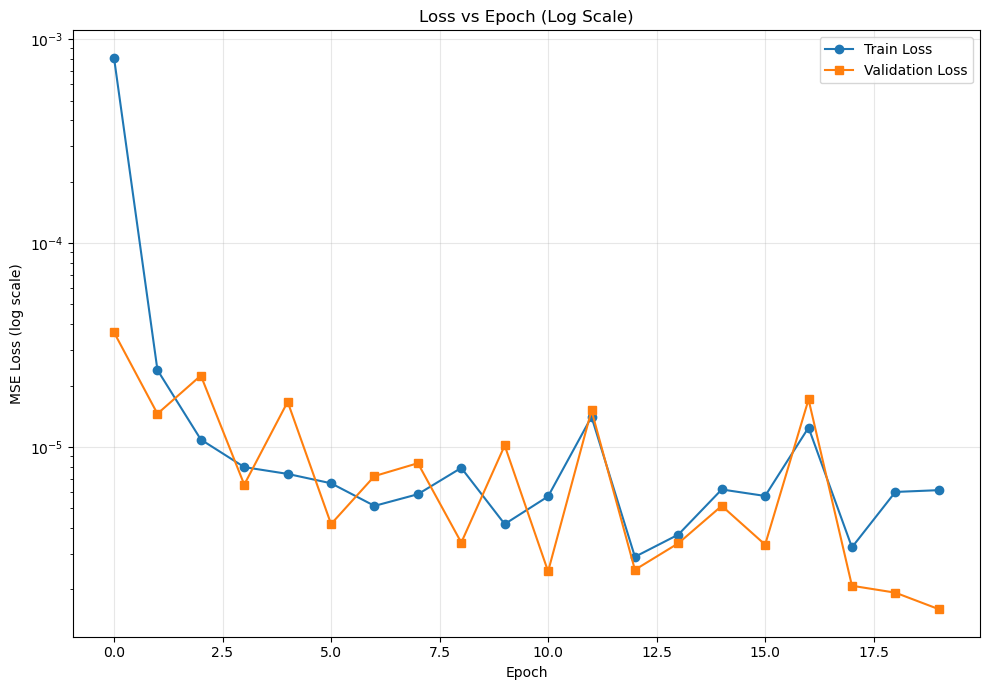

Final Train Loss      : 6.138238404673757e-06
Final Validation Loss : 1.6011587149478146e-06
Loss gap              : -4.5370796897259424e-06


In [157]:
plt.figure(figsize=(10,7))
plt.plot(history.history['loss'], marker='o', label='Train Loss')
plt.plot(history.history['val_loss'], marker='s', label='Validation Loss')
plt.yscale('log')
plt.xlabel('Epoch') 
plt.ylabel('MSE Loss (log scale)')
plt.title('Loss vs Epoch (Log Scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"Loss_vs_Epoch_LogScale.png"), dpi=1200)
plt.show()

print("Final Train Loss      :", history.history['loss'][-1])
print("Final Validation Loss :", history.history['val_loss'][-1])
print("Loss gap              :", history.history['val_loss'][-1] - history.history['loss'][-1])

In [158]:
# Accuracy percentages for a regression model
# For flow-field prediction, "accuracy" is not a native classification metric.
# So we compute regression-style percentages.
# ============================================================

def r2_score_np(y_true, y_hat):
    ss_res = np.sum((y_true - y_hat) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

# Overall R^2-based accuracy percentage
r2_overall = r2_score_np(y_test, y_pred)
r2_accuracy_pct = max(0.0, r2_overall) * 100

# Tolerance-based pixel accuracy in normalized units
# Here, a point is counted correct if absolute error < 0.05
tol = 0.05
pixel_accuracy_pct = np.mean(np.abs(y_test - y_pred) < tol) * 100

# Channel-wise metrics for u and v
r2_u = r2_score_np(y_test[...,0], y_pred[...,0])
r2_v = r2_score_np(y_test[...,1], y_pred[...,1])

u_accuracy_pct = max(0.0, r2_u) * 100
v_accuracy_pct = max(0.0, r2_v) * 100

print(f"Overall R^2 Accuracy (%)        : {r2_accuracy_pct:.2f}")
print(f"Pixel Accuracy @ |error|<0.05 % : {pixel_accuracy_pct:.2f}")
print(f"U-Velocity R^2 Accuracy (%)     : {u_accuracy_pct:.2f}")
print(f"V-Velocity R^2 Accuracy (%)     : {v_accuracy_pct:.2f}")

Overall R^2 Accuracy (%)        : 100.00
Pixel Accuracy @ |error|<0.05 % : 100.00
U-Velocity R^2 Accuracy (%)     : 99.96
V-Velocity R^2 Accuracy (%)     : 99.96


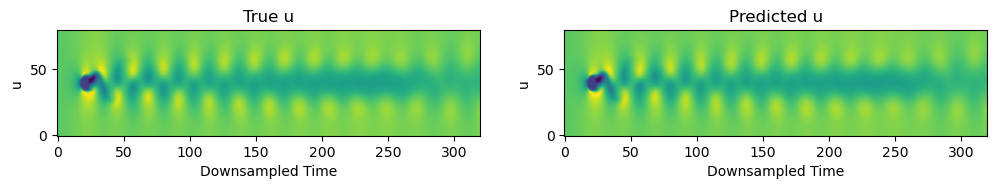

In [162]:
idx = 90

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(y_test[idx,:,:,0].T, origin='lower')
plt.title("True u")
plt.xlabel('Downsampled Time')
plt.ylabel('u')

plt.subplot(1,2,2)
plt.imshow(y_pred[idx,:,:,0].T, origin='lower')
plt.title("Predicted u")
plt.xlabel('Downsampled Time')
plt.ylabel('u')
plt.savefig(os.path.join(OUTPUT_DIR, f"True U vs Predicted U.png"), dpi=3600)
plt.show()

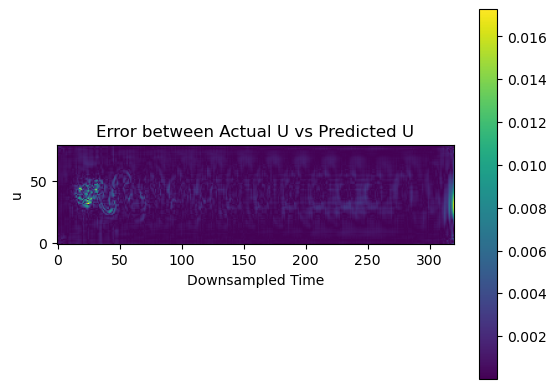

In [163]:
error = np.abs(y_test[idx] - y_pred[idx])

plt.imshow(error[:,:,0].T, origin='lower')
plt.title("Error between Actual U vs Predicted U")
plt.xlabel('Downsampled Time')
plt.ylabel('u')
plt.savefig(os.path.join(OUTPUT_DIR, f"Error between Actual U vs Predicted U.png"), dpi=3600)
plt.colorbar()
plt.show()

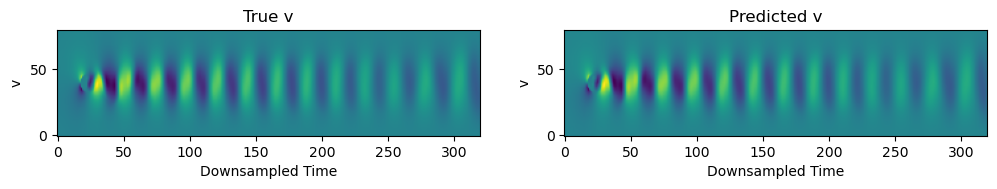

In [164]:
idx = 90

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(y_test[idx,:,:,1].T, origin='lower')
plt.title("True v")
plt.xlabel('Downsampled Time')
plt.ylabel('v')

plt.subplot(1,2,2)
plt.imshow(y_pred[idx,:,:,1].T, origin='lower')
plt.title("Predicted v")
plt.xlabel('Downsampled Time')
plt.ylabel('v')
plt.savefig(os.path.join(OUTPUT_DIR, f"True V vs Predicted V.png"), dpi=3600)
plt.show()

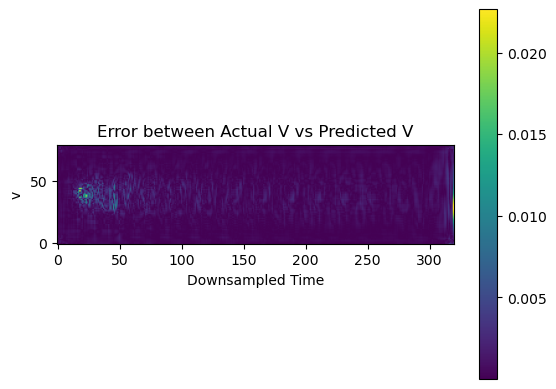

In [165]:
error = np.abs(y_test[idx] - y_pred[idx])
plt.imshow(error[:,:,1].T, origin='lower')
plt.title("Error between Actual V vs Predicted V")
plt.xlabel('Downsampled Time')
plt.ylabel('v')
plt.savefig(os.path.join(OUTPUT_DIR, f"Error between Actual V vs Predicted V.png"), dpi=3600)
plt.colorbar()
plt.show()

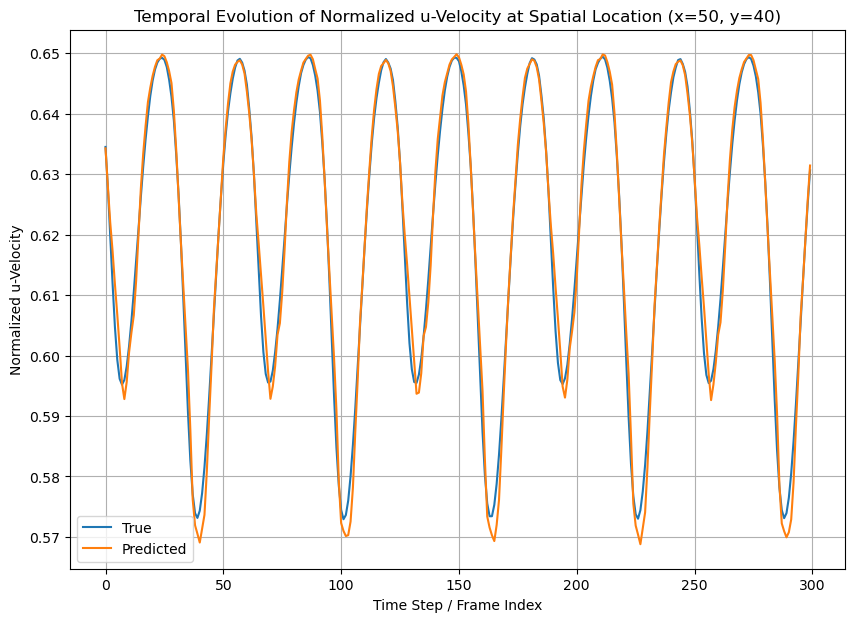

In [168]:
true_series = y_test[:, 50, 40, 0]
pred_series = y_pred[:, 50, 40, 0]

time_steps = np.arange(len(true_series))   # X-axis = temporal index / frame number

plt.figure(figsize=(10,7))
plt.plot(time_steps, true_series, label='True')
plt.plot(time_steps, pred_series, label='Predicted')

plt.xlabel("Time Step / Frame Index")
plt.ylabel("Normalized u-Velocity")
plt.title("Temporal Evolution of Normalized u-Velocity at Spatial Location (x=50, y=40)")

plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, f"Temporal Evolution.png"), dpi=3600, bbox_inches="tight")
plt.show()

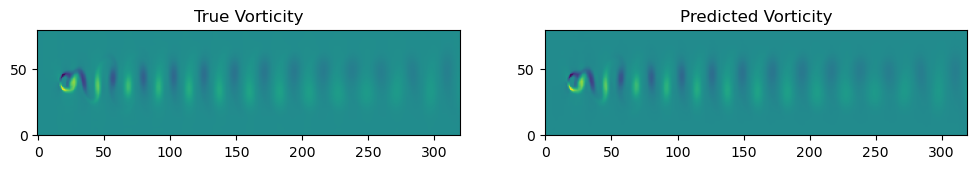

In [169]:
def vorticity(u, v):
    dvdx = np.gradient(v, axis=0)
    dudy = np.gradient(u, axis=1)
    return dvdx - dudy

omega_true = vorticity(y_test[idx,:,:,0], y_test[idx,:,:,1])
omega_pred = vorticity(y_pred[idx,:,:,0], y_pred[idx,:,:,1])

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(omega_true.T, origin='lower')
plt.title("True Vorticity")

plt.subplot(1,2,2)
plt.imshow(omega_pred.T, origin='lower')
plt.title("Predicted Vorticity")
plt.savefig(os.path.join(OUTPUT_DIR, f"True Vs Predicted Vorticity.png"), dpi=3600)
plt.show()

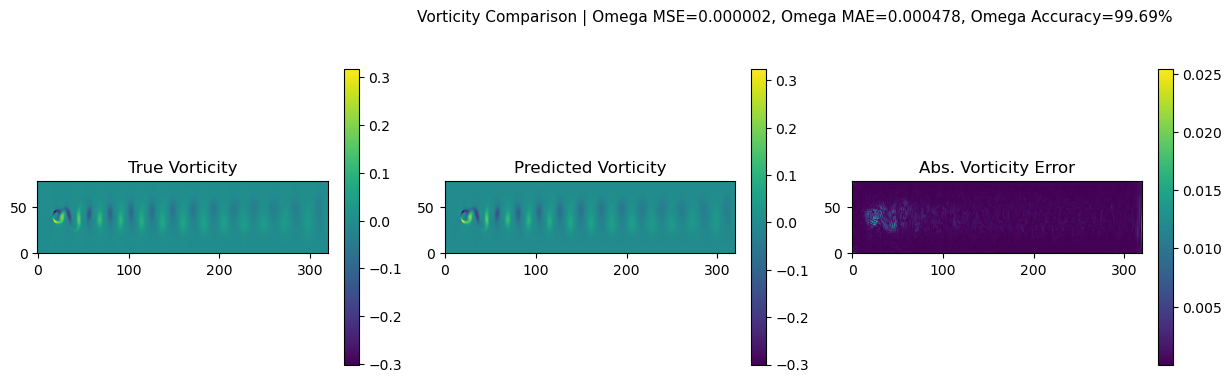

Vorticity MSE              : 0.000002
Vorticity MAE              : 0.000478
Vorticity R^2 Accuracy (%) : 99.69


In [171]:
# ============================================================
# vorticity error comparison with accuracy data
# ============================================================

omega_error = np.abs(omega_true - omega_pred)

# vorticity quality metrics
omega_mse = np.mean((omega_true - omega_pred)**2)
omega_mae = np.mean(np.abs(omega_true - omega_pred))
omega_r2 = r2_score_np(omega_true, omega_pred)
omega_accuracy_pct = max(0.0, omega_r2) * 100

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(omega_true.T, origin='lower')
plt.title("True Vorticity")
plt.colorbar(fraction=0.046)

plt.subplot(1,4,2)
plt.imshow(omega_pred.T, origin='lower')
plt.title("Predicted Vorticity")
plt.colorbar(fraction=0.046)

plt.subplot(1,4,3)
plt.imshow(omega_error.T, origin='lower')
plt.title("Abs. Vorticity Error")
plt.colorbar(fraction=0.046)

plt.suptitle(
    f"Vorticity Comparison | "
    f"Omega MSE={omega_mse:.6f}, Omega MAE={omega_mae:.6f}, "
    f"Omega Accuracy={omega_accuracy_pct:.2f}%",
    fontsize=11
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"Vorticity_Error_Comparison_with_Accuracy.png"), dpi=3600)
plt.show()

print(f"Vorticity MSE              : {omega_mse:.6f}")
print(f"Vorticity MAE              : {omega_mae:.6f}")
print(f"Vorticity R^2 Accuracy (%) : {omega_accuracy_pct:.2f}")

In [172]:
D = 0.125                  # cylinder diameter in simulation length units
x_min_phys = -0.5         # physical domain left edge
y_min_phys = -0.5        # physical domain bottom edge

NX, NY = y_test.shape[1], y_test.shape[2]
dx = 8.0 / NX             # stream-wise cell size
dy = 1.0 / NY             # cross-stream cell size

# Cell-center coordinates
x_phys_arr = x_min_phys + (np.arange(NX) + 0.5) * dx
y_phys_arr = y_min_phys + (np.arange(NY) + 0.5) * dy

# Nearest x-index to cylinder center x = 0
x_cyl_idx = np.argmin(np.abs(x_phys_arr - 0.0))

# IMPORTANT:
# y = 0 lies between two rows in this even-number grid, so use both nearest rows
y_sorted = np.argsort(np.abs(y_phys_arr - 0.0))
y_lower, y_upper = sorted(y_sorted[:2])   # typically 19 and 20 for NY = 40

print("Grid / physical setup")
print(f"NX = {NX}, NY = {NY}")
print(f"dx = {dx:.6f}, dy = {dy:.6f}")
print(f"x-cylinder nearest index = {x_cyl_idx}, x = {x_phys_arr[x_cyl_idx]:.6f}")
print(f"Wake centerline rows used = [{y_lower}, {y_upper}]")
print(f"y values of centerline rows = {y_phys_arr[y_lower]:.6f}, {y_phys_arr[y_upper]:.6f}")

# ── Probe definitions ─────────────────────────────────────────────────────────
probe_distances_D = [0.7, 1.3, 5.0]
#probe_distances_D = [0.1, 1.0, 3.0]

probe_x_phys = [dist * D for dist in probe_distances_D]
probe_x_idx = [np.argmin(np.abs(x_phys_arr - xp)) for xp in probe_x_phys]

print("\nProbe locations")
for dist, xi in zip(probe_distances_D, probe_x_idx):
    print(f"{dist:.1f}D  -> x-index = {xi}, x_phys = {x_phys_arr[xi]:.4f}, x/D = {x_phys_arr[xi]/D:.2f}")

# ── Centreline mean u-velocity (average of two middle rows) ─────────────────
u_mean_true = 0.5 * (
    y_test[:, :, y_lower, 0].mean(axis=0) +
    y_test[:, :, y_upper, 0].mean(axis=0)
)

u_mean_pred = 0.5 * (
    y_pred[:, :, y_lower, 0].mean(axis=0) +
    y_pred[:, :, y_upper, 0].mean(axis=0)
)

x_from_cyl_D = x_phys_arr / D
Lr_target = 1.05

Grid / physical setup
NX = 320, NY = 80
dx = 0.025000, dy = 0.012500
x-cylinder nearest index = 19, x = -0.012500
Wake centerline rows used = [39, 40]
y values of centerline rows = -0.006250, 0.006250

Probe locations
0.7D  -> x-index = 23, x_phys = 0.0875, x/D = 0.70
1.3D  -> x-index = 26, x_phys = 0.1625, x/D = 1.30
5.0D  -> x-index = 44, x_phys = 0.6125, x/D = 4.90


In [173]:
# ── Function to find recirculation length ─────────────────────────────────────
def find_Lr(u_mean_1d, x_from_cyl_D_1d):
    """
    Finds the downstream x/D where time-averaged centreline u first crosses
    zero from negative to positive. Returns NaN if no crossing exists.
    """
    mask = x_from_cyl_D_1d > 0
    x_ds = x_from_cyl_D_1d[mask]
    u_ds = u_mean_1d[mask]

    if np.min(u_ds) > 0:
        print("No recirculation detected: downstream centreline u stays positive.")
        return np.nan

    for i in range(len(u_ds) - 1):
        if u_ds[i] <= 0 < u_ds[i + 1]:
            x0, x1 = x_ds[i], x_ds[i + 1]
            u0, u1 = u_ds[i], u_ds[i + 1]
            return x0 - u0 * (x1 - x0) / (u1 - u0)

    print("Reverse flow exists, but no reattachment found within domain.")
    return np.nan

Lr_true = find_Lr(u_mean_true, x_from_cyl_D)
Lr_pred = find_Lr(u_mean_pred, x_from_cyl_D)

print("\nRecirculation length results")
print(f"TRUE min u_mean downstream: {u_mean_true[x_from_cyl_D > 0].min():.6f}")
print(f"PRED min u_mean downstream: {u_mean_pred[x_from_cyl_D > 0].min():.6f}")
print(f"Recirculation length — TRUE data : Lr = {Lr_true:.4f} D")
print(f"Recirculation length — U-Net pred: Lr = {Lr_pred:.4f} D")
print(f"Literature target               : Lr = {Lr_target:.2f} D")

if not np.isnan(Lr_true):
    err_true = abs(Lr_true - Lr_target)
    print(f"True error vs 1.05 D: {err_true:.4f} D ({100*err_true/Lr_target:.2f} %)")

if not np.isnan(Lr_pred):
    err_pred = abs(Lr_pred - Lr_target)
    print(f"U-Net error vs 1.05 D: {err_pred:.4f} D ({100*err_pred/Lr_target:.2f} %)")

No recirculation detected: downstream centreline u stays positive.
No recirculation detected: downstream centreline u stays positive.

Recirculation length results
TRUE min u_mean downstream: 0.267081
PRED min u_mean downstream: 0.266212
Recirculation length — TRUE data : Lr = nan D
Recirculation length — U-Net pred: Lr = nan D
Literature target               : Lr = 1.05 D


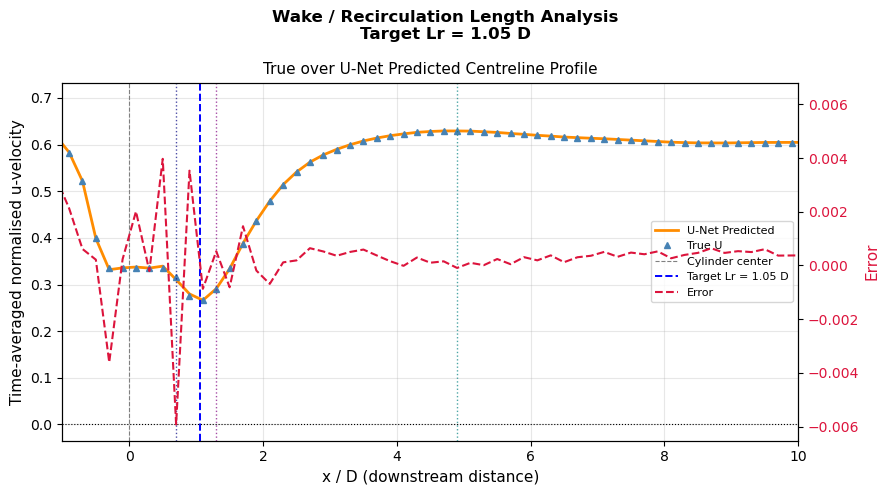

In [174]:
# ── Plot: True over Predicted with markers ────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 5))
plot_xlim = (-1, 10)

# Predicted as smooth line
ax1.plot(
    x_from_cyl_D, u_mean_pred,
    color='darkorange', lw=2,
    label='U-Net Predicted'
)

# True values over predicted using markers
ax1.plot (x_from_cyl_D, u_mean_true,color='steelblue', lw=0,marker='^', markersize=5, markevery=1, label='True U')

# Reference lines
ax1.axhline(0, color='k', lw=0.8, ls=':')
ax1.axvline(0, color='gray', lw=0.8, ls='--', label='Cylinder center')
ax1.axvline(Lr_target, color='blue', lw=1.4, ls='--',
            label=f'Target Lr = {Lr_target:.2f} D')

# Computed recirculation lengths
if not np.isnan(Lr_true):
    ax1.axvline(Lr_true, color='steelblue', lw=1.4, ls='-.',
                label=f'True Lr = {Lr_true:.3f} D')

if not np.isnan(Lr_pred):
    ax1.axvline(Lr_pred, color='darkorange', lw=1.4, ls='-.',
                label=f'Predicted Lr = {Lr_pred:.3f} D')

# Probe locations
for dist, xi, c in zip(probe_distances_D, probe_x_idx, ['navy', 'purple', 'teal']):
    ax1.axvline(x_phys_arr[xi] / D, color=c, lw=1.0, ls=':', alpha=0.7)

# Error on secondary axis
error = u_mean_pred - u_mean_true
ax2 = ax1.twinx()
ax2.plot(
    x_from_cyl_D, error,
    color='crimson', lw=1.5, ls='--',
    label='Error'
)
ax2.set_ylabel("Error", fontsize=11, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# Labels and style
ax1.set_xlim(plot_xlim)
ax1.set_xlabel("x / D (downstream distance)", fontsize=11)
ax1.set_ylabel("Time-averaged normalised u-velocity", fontsize=11)
ax1.set_title("True over U-Net Predicted Centreline Profile", fontsize=11)
ax1.grid(True, alpha=0.3)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='best')

fig.suptitle(
    f"Wake / Recirculation Length Analysis\n"
    f"Target Lr = {Lr_target:.2f} D", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "Recirculation_True_over_Predicted.png"),
    dpi=3600, bbox_inches='tight'
)
plt.show()

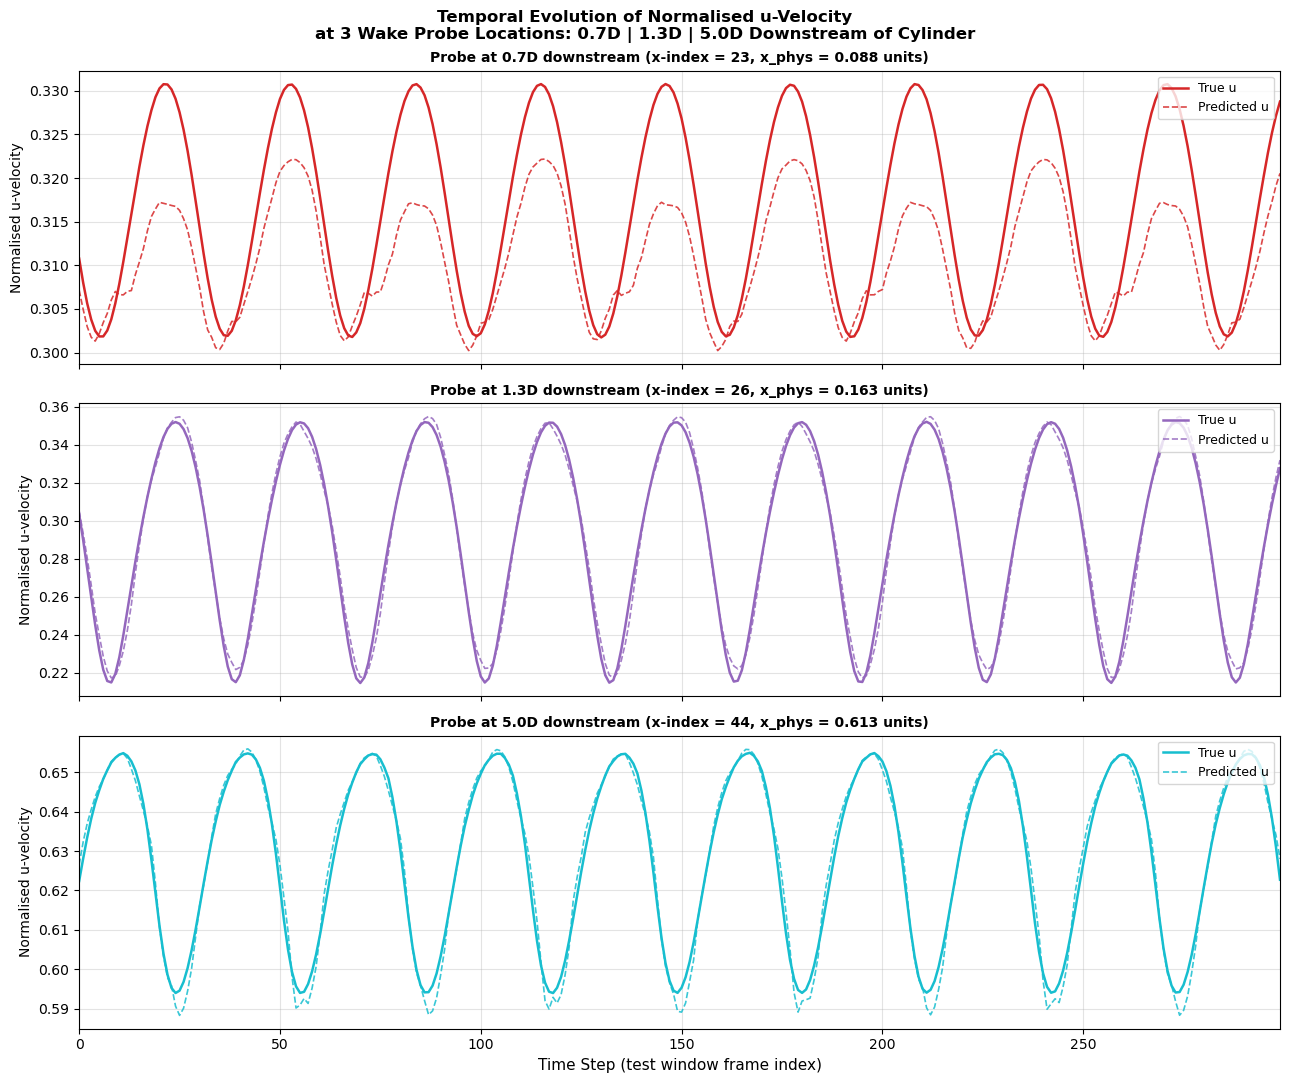

Saved: Temporal_Evolution_3_Probes.png


In [175]:
# ── Temporal evolution at 3 probes (use same two-row centerline average) ─────
true_u_probes = [
    0.5 * (y_test[:, xi, y_lower, 0] + y_test[:, xi, y_upper, 0])
    for xi in probe_x_idx
]

pred_u_probes = [
    0.5 * (y_pred[:, xi, y_lower, 0] + y_pred[:, xi, y_upper, 0])
    for xi in probe_x_idx
]

time_steps = np.arange(y_test.shape[0])

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
colours = ['#d62728', '#9467bd', '#17becf']

for ax, true_u, pred_u, xi, dist, col in zip(
    axes, true_u_probes, pred_u_probes, probe_x_idx, probe_distances_D, colours
):
    ax.plot(time_steps, true_u, color=col, lw=1.8, label='True u')
    ax.plot(time_steps, pred_u, color=col, lw=1.2, ls='--', alpha=0.85, label='Predicted u')

    ax.set_xlim(0, time_steps[-1])   # remove left and right empty space
    ax.margins(x=0)                  # no automatic x-padding

    ax.set_ylabel("Normalised u-velocity", fontsize=10)
    ax.set_title(
        f"Probe at {dist:.1f}D downstream (x-index = {xi}, x_phys = {x_phys_arr[xi]:.3f} units)",
        fontsize=10, fontweight='bold'
    )
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.35)

axes[-1].set_xlabel("Time Step (test window frame index)", fontsize=11)
fig.suptitle(
    "Temporal Evolution of Normalised u-Velocity\n"
    "at 3 Wake Probe Locations: 0.7D | 1.3D | 5.0D Downstream of Cylinder",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Temporal_Evolution_3_Probes.png"), dpi=3600, bbox_inches='tight')
plt.show()

print("Saved: Temporal_Evolution_3_Probes.png")

It shows a time-history comparison of streamwise velocity, 
𝑢
u at three probe locations behind a circular cylinder in the wake, using both true CFD/data values and predicted values from your model.

The x-axis is the time step and the y-axis is the normalized 
𝑢
u-velocity. Each subplot tracks how the wake velocity changes over time at a fixed downstream location:

P1 = 0.7D downstream
P2 = 1.3D downstream
P3 = 5.0D downstream

The solid line is the true 
𝑢
u-velocity, and the dashed line is the predicted 
𝑢
u-velocity from the model. Their closeness tells you how well the model captures the temporal wake behavior.

The horizontal dotted black line is the 
𝑢

u=0 physical threshold, shown here after normalization. This is very important because:

Below this line means negative streamwise velocity, or reversed flow
Reversed flow indicates the point is inside the recirculation zone behind the cylinder
The shaded red region marks those reversed-flow intervals.

What each probe says physically:

P1 — 0.7D downstream:
This point is labeled inside the recirculation bubble. The velocity stays close to the threshold, meaning this region is in or very near the separated wake behind the cylinder. The prediction also remains close to the true signal, so the model is capturing near-body wake behavior reasonably well.

P2 — 1.3D downstream:
This location is marked near reattachment, around the target recirculation length 
𝐿
𝑟
≈
1.05
𝐷
L
r
≈1.05D. The oscillations here show the flow is transitioning from the reversed-flow region back toward forward flow. This is often one of the most sensitive wake locations because it sits near the end of the recirculation bubble.

P3 — 5.0D downstream:
This is in the far wake, where vortex shedding is fully developed. The signal has stronger periodic oscillations and remains well above the reversed-flow threshold, meaning the flow here is no longer recirculating. Instead, it reflects the regular unsteady wake dynamics downstream.

probe_x_idx = [max(0, min(xi, NX - 1)) for xi in probe_x_idx]
u_zero_norm = (0.0 - flow_min) / (flow_max - flow_min)
print(f"flow_min = {flow_min:.4f}   flow_max = {flow_max:.4f}")
print(f"Normalised u=0 threshold : {u_zero_norm:.4f}")
print(f"Probe x-indices          : {probe_x_idx}  (grid space)")
print(f"Probe distances          : {probe_distances_D} D  (physical)")
print(f"Recirculation Lr target  : 1.05 D")

fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

probe_titles = [
    f"P1 — 0.7D downstream  (x-idx={probe_x_idx[0]})  |  INSIDE recirculation bubble",
    f"P2 — 1.3D downstream  (x-idx={probe_x_idx[1]})  |  Near reattachment  (Lr ≈ 1.05D)",
    f"P3 — 5.0D downstream  (x-idx={probe_x_idx[2]})  |  Established far wake",
]
colours = ['#d62728', '#9467bd', '#17becf']
time_steps = np.arange(y_test.shape[0])

for ax, true_u, pred_u, title, col in zip(
        axes, true_u_probes, pred_u_probes, probe_titles, colours):

    ax.plot(time_steps, true_u, color=col, lw=1.8, label='True u')
    ax.plot(time_steps, pred_u, color=col, lw=1.2, ls='--',
            alpha=0.85, label='Predicted u')

    # u_phys = 0 threshold (boundary of recirculation / forward flow)
    ax.axhline(u_zero_norm, color='black', lw=1.2, ls=':',
               label=f'u_phys=0  (norm={u_zero_norm:.3f})')

    # Shade the recirculation region (u_norm < u_zero_norm → reversed flow)
    ax.fill_between(time_steps,
                    np.minimum(true_u, u_zero_norm), u_zero_norm,
                    where=(true_u < u_zero_norm),
                    alpha=0.15, color='red', label='Reversed flow (recirculation)')

    ax.set_ylabel("Normalised u", fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right', ncol=2)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

axes[-1].set_xlabel("Time Step (test-set frame index)", fontsize=11)
fig.suptitle(
    "Temporal u-Velocity at 3 Wake Probes with Recirculation Threshold\n"
    "0.7D | 1.3D | 5.0D downstream  —  Lr target = 1.05 D  (D = 0.1 units)",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"Temporal_Probes_Recirculation_Threshold.png"), dpi=1200, bbox_inches='tight')
plt.show()